In [ ]:
%pip install kagglehub[pandas-datasets]


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<h1>Treinando o algoritmo de clusterização Spectral Clustering</h1>

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "iris.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "himanshunakrani/iris-dataset",
  file_path
)

print("First 5 records:", df.head())

C:\Users\maria\AppData\Local\Temp\ipykernel_1736\220261672.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
from sklearn.cluster import SpectralClustering

def aplicar_spectral_clustering(dados, n_clusters):
    spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
    spectral.fit(dados)
    return spectral.labels_


def visualizar_clusters(dados_2d, labels):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    plt.scatter(dados_2d.iloc[:, 0], dados_2d.iloc[:, 1], c=labels, cmap='viridis', marker='o')
    plt.title('Clusters Identificados pelo Spectral Clustering')
    plt.xlabel(dados_2d.columns[0])
    plt.ylabel(dados_2d.columns[1])
    plt.colorbar(label='Cluster Label')
    plt.show()


def metricas_avaliacao(dados, labels):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

    silhouette = silhouette_score(dados, labels)
    calinski_harabasz = calinski_harabasz_score(dados, labels)
    davies_bouldin = davies_bouldin_score(dados, labels)

    return {
        'Silhouette Score': silhouette,
        'Calinski-Harabasz Index': calinski_harabasz,
        'Davies-Bouldin Index': davies_bouldin
    }

In [8]:
aplicar_spectral_clustering(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 3)

c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], dtype=int32)

c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


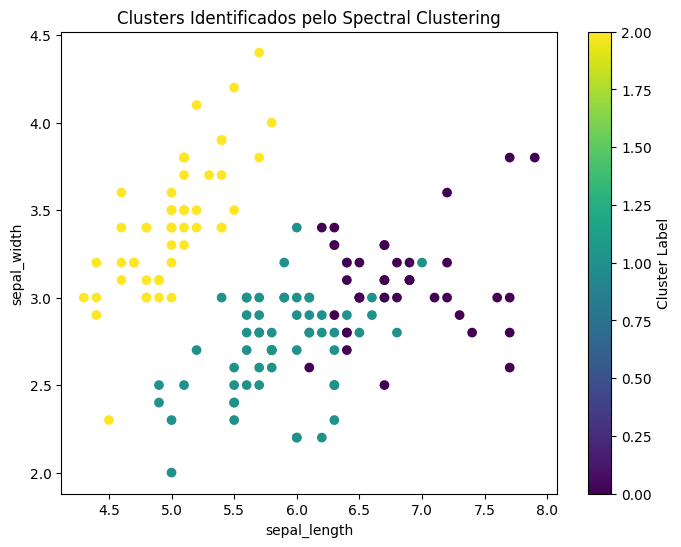

In [10]:
visualizar_clusters(df[['sepal_length', 'sepal_width']], aplicar_spectral_clustering(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 3))

In [ ]:
metricas_avaliacao(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], aplicar_spectral_clustering(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 3))

c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


{'Silhouette Score': 0.5539343898551252,
 'Calinski-Harabasz Index': 555.6662156584963,
 'Davies-Bouldin Index': 0.658791882943679}